In [8]:
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics import r2_score


# Advertising Spend vs. Sales Revenue: Data Modeling Project

## Introduction
 
In this project, we explore the relationship between a company's advertising spending and its sales revenue. The goal is to determine whether increased investment in advertising leads to higher sales, using a simple data modeling approach.

This analysis is based on a synthetic dataset representing 24 months of financial data for a fictional company. The dataset includes monthly advertising spend and corresponding sales revenue. We will use Python to perform exploratory data analysis, calculate correlations, and build a simple linear regression model to quantify the relationship between advertising and sales.
 
The project is designed to demonstrate basic data modeling skills using Python and Jupyter Notebook, with a focus on clear analysis, visualization, and interpretation of results.

In [13]:
# Load the dataset
df = pd.read_csv("finance_advertising_sales_data.csv")
 
# Preview the first few rows
df.tail()



,Month,Advertising_Spend,Sales_Revenue
19,20,7.91,90.53
20,21,11.12,109.29
21,22,6.39,82.81
22,23,7.92,89.02
23,24,8.66,91.79


In [7]:
# Basic info about the dataset
df.info()
 
# Summary statistics
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Month              24 non-null     int64  
 1   Advertising_Spend  24 non-null     float64
 2   Sales_Revenue      24 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 708.0 bytes


,Month,Advertising_Spend,Sales_Revenue
count,24.000000,24.000000,24.000000
mean,12.500000,9.401250,96.000417
std,7.071068,2.913701,16.360391
min,1.000000,5.210000,72.150000
25%,6.750000,6.827500,83.215000
50%,12.500000,8.705000,91.345000
75%,18.250000,11.360000,109.027500
max,24.000000,14.700000,132.760000


## Exploratory Data Analysis (EDA)
 
In this section, we will explore the dataset to understand the distribution of advertising spend and sales revenue. We will compute basic statistics, identify trends, and prepare the data for modeling.

In [8]:
# Summary statistics for each column
df.describe()

,Month,Advertising_Spend,Sales_Revenue
count,24.000000,24.000000,24.000000
mean,12.500000,9.401250,96.000417
std,7.071068,2.913701,16.360391
min,1.000000,5.210000,72.150000
25%,6.750000,6.827500,83.215000
50%,12.500000,8.705000,91.345000
75%,18.250000,11.360000,109.027500
max,24.000000,14.700000,132.760000


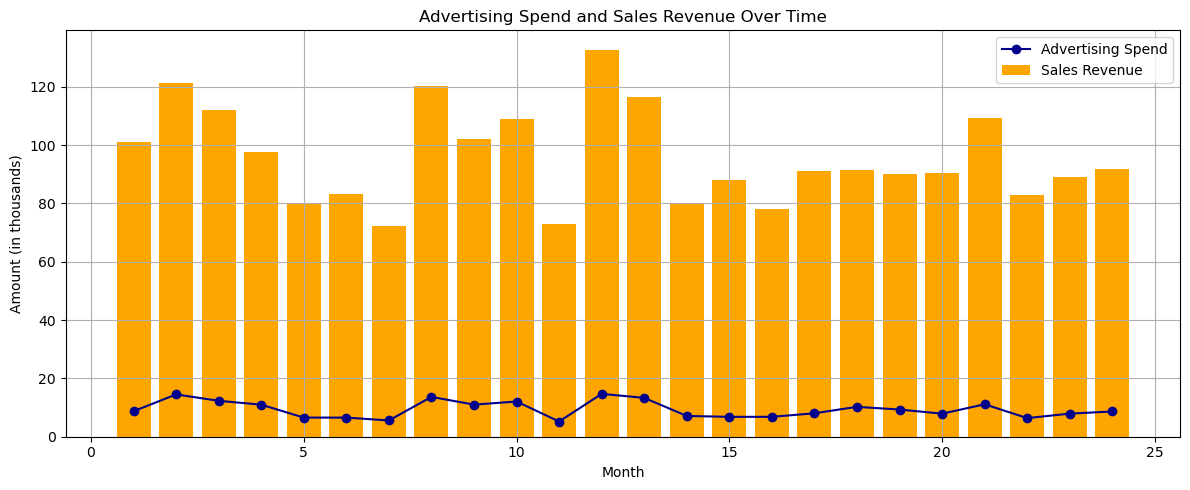

In [17]:
# Plotting Advertising Spend and Sales Revenue over time
plt.figure(figsize=(12, 5))
 
# Advertising Spend - Bar
plt.plot(df['Month'], df['Advertising_Spend'], label='Advertising Spend', color="darkblue",marker='o')
 
# Sales Revenue - Line
plt.bar(df['Month'], df['Sales_Revenue'], label='Sales Revenue', color="orange", )
 
plt.title('Advertising Spend and Sales Revenue Over Time')
plt.xlabel('Month')
plt.ylabel('Amount (in thousands)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Let's check how strongly advertising and sales are related:

In [24]:
# Calculate correlation between Advertising Spend and Sales Revenue
correlation = df['Advertising_Spend'].corr(df['Sales_Revenue'])
print(f"Correlation between Advertising Spend and Sales Revenue: {correlation:.2f}")

Correlation between Advertising Spend and Sales Revenue: 0.96


### Key Insights from EDA
 
- The average advertising spend over 24 months is approximately **9.4** thousand.
- The average sales revenue is approximately **96** thousand.
- The correlation between advertising spend and sales revenue is **0.96**, indicating a strong positive relationship.
- From the line chart, we observe that sales tend to increase in months with higher advertising spend, suggesting a potential linear relationship.

## Modeling the Relationship (Linear Regression)
 
To understand how advertising spend influences sales revenue, we will build a simple linear regression model. This model will help us quantify the relationship and make predictions based on advertising investment

In [17]:
# Reshape the data for sklearn
X = df[['Advertising_Spend']]  # Independent variable
y = df['Sales_Revenue']        # Dependent variable
 
# Create and fit the model
model = LinearRegression()
model.fit(X, y)
 
# Get the slope (coefficient) and intercept
slope = model.coef_[0]
intercept = model.intercept_
 
print(f"Linear Regression Equation: Sales_Revenue = {intercept:.2f} + {slope:.2f} * Advertising_Spend")

Linear Regression Equation: Sales_Revenue = 45.13 + 5.41 * Advertising_Spend


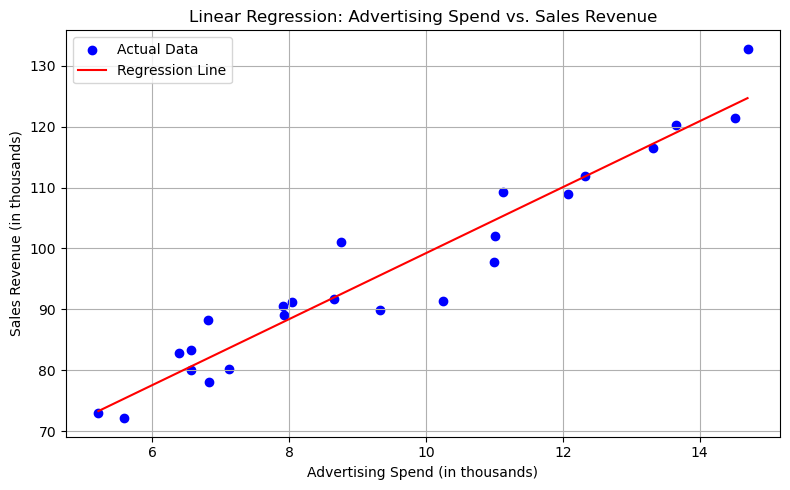

In [19]:
# Scatter plot of the data
plt.figure(figsize=(8, 5))
plt.scatter(df['Advertising_Spend'], df['Sales_Revenue'], color='blue', label='Actual Data')
 
# Regression line
x_vals = np.linspace(df['Advertising_Spend'].min(), df['Advertising_Spend'].max(), 100)
y_vals = intercept + slope * x_vals
plt.plot(x_vals, y_vals, color='red', label='Regression Line')
 
plt.title('Linear Regression: Advertising Spend vs. Sales Revenue')
plt.xlabel('Advertising Spend (in thousands)')
plt.ylabel('Sales Revenue (in thousands)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretation of the Model
 
The linear regression model suggests the following relationship:
 
**Sales_Revenue = 45.13 + 5.41 × Advertising_Spend**
 
This means that for every additional thousand spent on advertising, the sales revenue increases by approximately **5.41 thousand**.
 
The regression line fits the data well, indicating a strong linear relationship between advertising spend and sales revenue.
 

# Making Predictions
 
Now that we have a trained linear regression model, we can use it to predict future sales revenue based on new advertising spend values. This allows us to estimate the potential return on investment for different advertising budgets.

In [21]:
# Example: Predict sales for new advertising spend values
new_spend = pd.DataFrame({'Advertising_Spend': [6, 10, 12, 15]})
predicted_sales = model.predict(new_spend)
 
# Combine into a single DataFrame for display
prediction_results = new_spend.copy()
prediction_results['Predicted_Sales_Revenue'] = predicted_sales.round(2)
prediction_results

,Advertising_Spend,Predicted_Sales_Revenue
0,6,77.60
1,10,99.24
2,12,110.06
3,15,126.29


### Prediction Results
 
The table above shows the predicted sales revenue for different levels of advertising spend. For example, if the company spends 10 thousand on advertising, the model predicts a sales revenue of approximately **99** thousand.
 
These predictions can help guide budgeting decisions by estimating the expected return from various advertising investments.

In [23]:
# Predict sales using the model
y_pred = model.predict(X)
 
# Calculate R² score
r2 = r2_score(y, y_pred)
print(f"R² Score: {r2:.2f} — This means the model explains approximately {r2 * 100:.1f}% of the variance in sales revenue.")

R² Score: 0.93 — This means the model explains approximately 92.9% of the variance in sales revenue.


## Final Summary and Conclusion
 
### Model Evaluation
 
- The linear regression model achieved an R² score of **0.93**, indicating that approximately **92.9%%** of the variance in sales revenue can be explained by advertising spend.
- The model equation was: 
  **Sales_Revenue = 45.13 + 5.41 × Advertising_Spend**
- This suggests that for every additional thousand spent on advertising, sales revenue increases by approximately **5.41 thousand**.
- The regression line fit the data well, confirming a strong linear relationship between advertising spend and sales revenue.
 
### Prediction Insights
 
- Using the trained model, we predicted sales revenue for new advertising spend values.
- For example, if the company spends 10 thousand on advertising, the model predicts a sales revenue of approximately **99** thousand.
- These predictions provide a practical way to estimate the return on investment for different advertising budgets and can support strategic financial planning.
 
### Conclusion
 
This project demonstrated how basic data modeling techniques can be applied to a financial scenario. By creating a synthetic dataset and using Python for analysis, we explored the relationship between advertising and sales, built a regression model, and used it to make actionable predictions. The results show how even simple models can provide valuable insights for business decision-making.